# Jak dobrze są opłacane oferty pracy i umiejętności dla analityka danych?

##### załadowane danych i wstępne oczyszczenie danych

In [1]:
import ast 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt  
from datasets import load_dataset

def clean_list(skill_list):
    if pd.notna(skill_list):
        return ast.literal_eval(skill_list)

#loading data
datasets = load_dataset('lukebarousse/data_jobs')
df = datasets['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(clean_list)

oferty tylko w stanach zjednoczonych

In [2]:
df_us = df[df['job_country'] == 'United States'].copy()
df_us = df_us.dropna(subset=['salary_year_avg'])


top 6 stanowisk

In [15]:
jobs_list = df.job_title_short.value_counts().index[:6].tolist()


In [16]:
jobs_list

['Data Analyst',
 'Data Engineer',
 'Data Scientist',
 'Business Analyst',
 'Software Engineer',
 'Senior Data Engineer']

data frame tylko dla top 6 stanowisk

In [20]:
df_us_top_6 = df_us[df_us['job_title_short'].isin(jobs_list)]

In [21]:
# Obliczenie mediany wynagrodzeń dla każdego z 6 najpopularniejszych stanowisk i posortowanie ich malejąco
order_median = df_us_top_6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index.tolist()

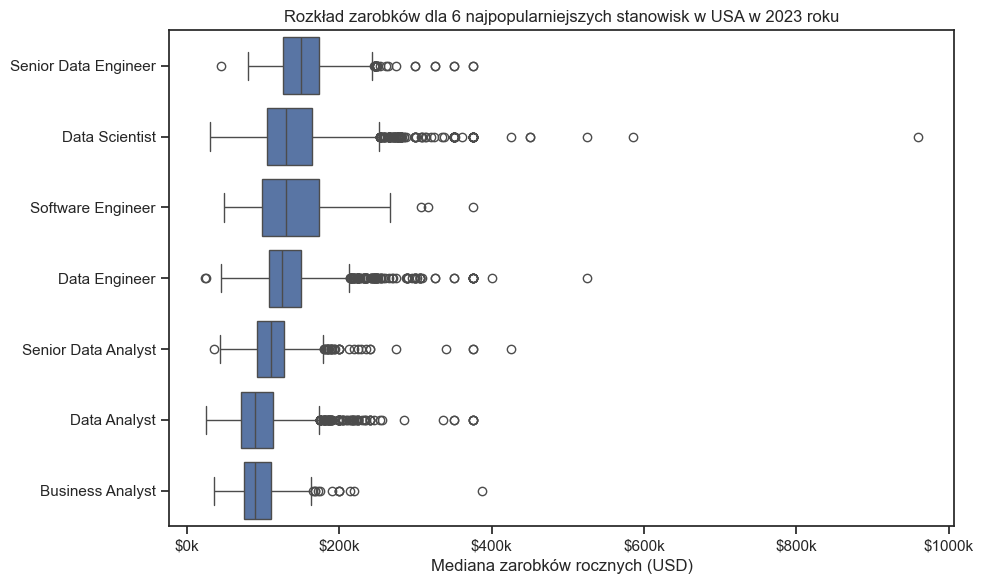

In [22]:
sns.set_theme(style="ticks")
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(y='job_title_short', x='salary_year_avg', data=df_us_top_6, order=order_median)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}k'))
plt.title('Rozkład zarobków dla 6 najpopularniejszych stanowisk w USA w 2023 roku')
plt.xlabel('Mediana zarobków rocznych (USD)')
plt.ylabel('')
plt.tight_layout()
plt.show()

Mediana zarobków dla umiejętności dla analityka danych

In [7]:
df_da_us = df_us[df_us['job_title_short'] == 'Data Analyst']

In [8]:
df_skills = df_da_us.explode('job_skills')
skills_stats = df_skills.groupby('job_skills').agg(
    skills_count=('job_skills', 'count'),
    skills_median = ('salary_year_avg', 'median')
)

In [9]:
skills_highest_median = skills_stats.sort_values('skills_median', ascending=False).head(5)
skills_most_demanded = skills_stats.sort_values('skills_count', ascending=False).head(5).sort_values('skills_median', ascending=False)

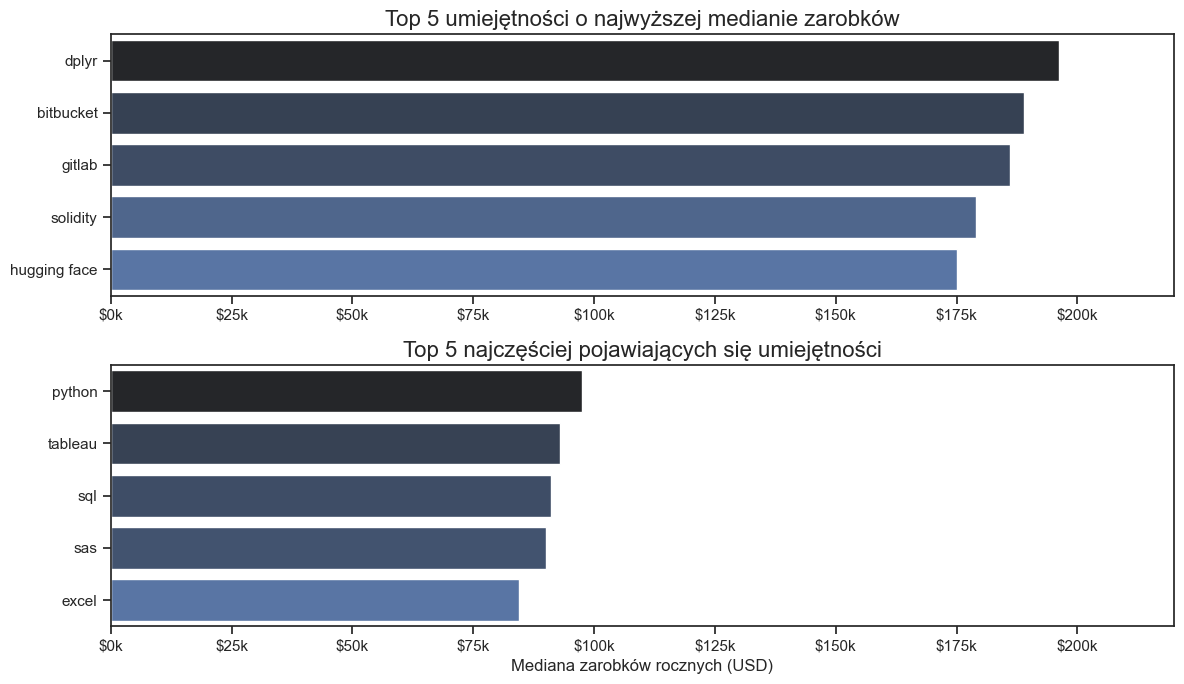

In [24]:
fig, ax = plt.subplots(2,1, figsize=(12, 7))   
for i, skills in enumerate([skills_highest_median, skills_most_demanded]):
    sns.barplot(
        y=skills.index,
        x=skills['skills_median'],
        ax=ax[i], palette='dark:b_r',
        hue=skills['skills_median'],
        legend=False)
    ax[i].set_title('Top 5 umiejętności o najwyższej medianie zarobków' if i == 0 else 'Top 5 najczęściej pojawiających się umiejętności', fontsize=16)
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')
    ax[i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}k'))
    ax[i].set_xlim(0, 220_000)

plt.xlabel('Mediana zarobków rocznych (USD)')
plt.tight_layout()
plt.show()
